# Adaptation from saved trajectories

Read saved results, inspect the numbers, draw figures, and export a new snapshot.
This notebook runs independently of the other notebooks.
`OWNED_TABLES` below lists the CSVs exported here; figure names appear in
the drawing cells.

**Inputs:** all saved monitors and parameter trajectories. No training runs here. Additional computation is opt-in in the final analysis chapter.
**Use:** run from the top once. For presentation edits, rerun only that chapter's
display-settings and drawing cells. For changes to inputs or display targets,
restart the kernel and run all cells so that every chapter uses the same conditions.
Save the notebook file before exporting to include your code in the source copy.

## 1. Settings

Shared defaults are in `figure_settings.py`; the next cell reloads them.
`DISPLAY_TARGETS=None` selects the lowest seed-median final classifier validation
loss for each model. Ties within absolute 1e-6 (relative tolerance zero) choose
the smaller target. A model dictionary changes the display only; HP eta selection
remains unchanged. PDF is OFF by default. Viewing creates no files.

In [1]:
from pathlib import Path
import sys
import json
import importlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents)
            if (p / "experiment_settings.py").is_file() and (p / "src/hnn2").is_dir())
sys.path.insert(0, str(ROOT))
sys.path.insert(0, str(ROOT / "src"))
sys.path.insert(0, str(ROOT / "notebooks"))
import figure_settings
defaults = importlib.reload(figure_settings)

from hnn2.figure_tables import KEYS, _identity, load_figure_runs, require_complete, analysis_target_tables, check_figure_inputs, selected_runs, save_figure_tables
from hnn2.plots import MODEL_COLORS
from hnn2.figure_plots import _arm_label, save_basic_figures
import hashlib

In [2]:
RESULTS = Path(defaults.RESULTS_ROOT)
OUTPUT = Path(defaults.OUTPUT)
DISPLAY_TARGETS = defaults.DISPLAY_TARGETS
SAVE_NUMBERS = defaults.SAVE_NUMBERS
SAVE_PNG = defaults.SAVE_PNG
SAVE_PDF = defaults.SAVE_PDF  # False by default; enable explicitly when needed.
SHOW_FIGURES = defaults.SHOW_FIGURES
EXPORT_NAME = defaults.EXPORT_NAME

RUN_ADDITIONAL_INFERENCE = False  # Explicit computation; never triggered by ordinary plotting.
ADDITIONAL_PATH = OUTPUT / "additional" / "adaptation_v1"

In [3]:
NOTEBOOK_OWNER = 'adaptation'
NOTEBOOK_PATH = ROOT / "notebooks" / '02_adaptation.ipynb'
OWNED_TABLES = ['monitor']

## 2. Load and check results

All five result notebooks require the complete saved run artifacts, planned
run lists, HP selection, and recorded dataset files, even when a chapter uses
only some of those inputs. The coverage table includes every planned run,
including missing or invalid runs. The notebook stops on incomplete data.

Source hashes, HP eta, scientific conditions, budgets, and seed populations
are checked before comparisons. Effective targets and displayed seeds below
are the conditions for this kernel.

In [4]:
selection_directory = RESULTS / "hp/selection"
runs, expected = load_figure_runs(RESULTS)
display(expected.groupby(["arm", "state"], dropna=False).size().rename("runs").reset_index())
display(expected.loc[expected.state != "complete", ["run", "state", "reason"]])
require_complete(expected)

# Assemble all targets before applying the shared display-selection rule.
parts = []
for path, (conditions, arrays, saved) in runs.items():
    frame = saved["summary"].assign(**_identity(path, conditions))
    frame["n_readout_parameters"] = (frame.n_features + 1) * frame.n_classes
    frame["final_model"] = "last_step; best_val_accuracy is monitoring_only"
    frame["readout_eval_every"] = conditions["config"]["readout_eval_every"]
    frame["readout_epochs"] = conditions["config"]["readout_epochs"]
    parts.append(frame)
summary = pd.concat(parts, ignore_index=True)
candidates, effective = analysis_target_tables(summary, DISPLAY_TARGETS)
targets = effective.set_index("model_code").targ.to_dict()
report, coverage = check_figure_inputs(runs, expected, selection_directory, targets)
selected = selected_runs(runs, targets)
chosen_paths = set(selected)
chosen = summary[summary.run.isin(chosen_paths)].reset_index(drop=True)
models = [model for model in ("rec", "ff", "thresh") if model in targets]
arms = [f"{model}_{stage}" for model in models for stage in ("initial", "trained")] + ["raw", "mlp_frozen"]
arm_labels = [_arm_label(arm, targets) for arm in arms]
tables = {"summary": summary, "selected_summary": chosen}
figures = {}
display(effective)
display(chosen.groupby("arm").seed_index.agg(list).rename("displayed_seeds").to_frame())
print(f"Input: {RESULTS.resolve()}\nOutput: {OUTPUT.resolve()}")
print("Invalid or missing planned runs:", int(coverage.state.ne("complete").sum()))

,arm,state,runs
0,ff_initial,complete,3
1,ff_trained,complete,27
2,mlp_frozen,complete,3
3,raw,complete,3
4,rec_initial,complete,3
5,rec_trained,complete,27
6,thresh_initial,complete,3
7,thresh_trained,complete,27


,run,state,reason


,model_code,targ,method,median_final_val_loss,tiebreak
0,ff,0.55,median_final_val_loss,0.449672,absolute difference <= 1e-06 from the best see...
1,rec,0.17,median_final_val_loss,0.368852,absolute difference <= 1e-06 from the best see...
2,thresh,1.55,median_final_val_loss,0.649693,absolute difference <= 1e-06 from the best see...


,displayed_seeds
arm,
ff_initial,"[0, 1, 2]"
ff_trained,"[0, 1, 2]"
mlp_frozen,"[0, 1, 2]"
raw,"[0, 1, 2]"
rec_initial,"[0, 1, 2]"
rec_trained,"[0, 1, 2]"
thresh_initial,"[0, 1, 2]"
thresh_trained,"[0, 1, 2]"


Input: outputs\synthetic_long_v1\results
Output: outputs\synthetic_long_v1\analysis\notebook_figures_v2
Invalid or missing planned runs: 0


### Export helper

Chapter saves are opt-in at the end of each chapter. The final export saves
the CSVs listed in `OWNED_TABLES` and the prepared main-chapter figures.
Each save uses a **new name** under `OUTPUT / NOTEBOOK_OWNER`; existing
folders are rejected. Change the name after editing a figure.

PNG and PDF use the switches above. Numeric tables and source records are
saved even if both image switches are OFF.

In [5]:
def export_section(name, figure_names, table_names):
    """Save this chapter to a new directory with its numeric sources."""
    if Path(name).name != name or name in ("", ".", ".."):
        raise ValueError("Use a simple new export name, without directories")
    if not set(table_names) <= set(OWNED_TABLES):
        raise ValueError("Only this notebook's tables may be exported")
    destination = OUTPUT / NOTEBOOK_OWNER / name
    if destination.exists():
        raise FileExistsError(f"Choose a new export name: {destination}")
    # Resolve selections before creating files, so a missing chapter fails early.
    numeric = {key: tables[key] for key in table_names}
    images = {key: figures[key] for key in figure_names}
    numeric_path = save_figure_tables(
        destination / "tables/figures", numeric, runs, targets=targets,
        selection_directory=selection_directory, notebook_path=NOTEBOOK_PATH,
        coverage=coverage, analysis_targets=effective,
    )
    settings = {"results": str(RESULTS.resolve()), "output": str(OUTPUT.resolve()),
                "display_targets": DISPLAY_TARGETS, "effective_targets": targets,
                "png": SAVE_PNG, "pdf": SAVE_PDF, "export_name": name,
                "figures": list(images), "tables": list(numeric)}
    (numeric_path / "notebook_settings.json").write_text(
        json.dumps(settings, indent=2), encoding="utf-8")
    save_basic_figures(images, destination / "figures", png=SAVE_PNG,
                       pdf=SAVE_PDF, numeric_source=numeric_path)
    print(f"Saved: {destination}")
    return destination

## 3. Mean activity and residuals

Monitor rows retain every target. Mean-activity plots use the selected target; residual plots compare all targets at the final epoch.

In [6]:
parts = []
for path, (conditions, arrays, saved) in runs.items():
    if "monitor" not in saved:
        continue
    identity = _identity(path, conditions)
    frame = saved["monitor"].assign(**identity)
    frame["monitor_split"] = conditions["config"]["monitor_probe_split"]
    # Target-relative errors use both rate averages on monitor and train splits.
    for suffix in ("", "_train"):
        for kind in ("mean", "wmean"):
            frame[f"residual_{kind}{suffix}"] = abs(frame[f"rate_{kind}{suffix}"] - identity["targ"]) / identity["targ"]
    parts.append(frame)
tables["monitor"] = pd.concat(parts, ignore_index=True)

In [7]:
for name in ['monitor']:
    print(f"{name}: {len(tables[name])} rows (preview below; export keeps every row)")
    display(tables[name].head(12).rename(columns={"lifetime": "dataset"}).replace({"axis": {"lifetime": "dataset"}}))

monitor: 810 rows (preview below; export keeps every row)


,l_mean,rate_var,composite,rate_mean,rate_wmean,rate_mean_train,rate_wmean_train,epoch,eta,run,arm,model_code,targ,seed_index,monitor_split,residual_mean,residual_wmean,residual_mean_train,residual_wmean_train
0,0.028735,0.000006,0.028740,0.000487,0.000275,0.000441,0.000238,0,0.0003,[local path],ff_trained,ff,0.17,0,val,0.997133,0.998381,0.997406,0.998598
1,0.010670,0.003373,0.014043,0.066704,0.060466,0.063161,0.056315,1,0.0003,[local path],ff_trained,ff,0.17,0,val,0.607622,0.644320,0.628466,0.668736
2,0.000253,0.000577,0.000830,0.185905,0.180449,0.178908,0.171516,2,0.0003,[local path],ff_trained,ff,0.17,0,val,0.093559,0.061465,0.052398,0.008919
3,0.000090,0.000305,0.000395,0.179509,0.173931,0.172530,0.165036,3,0.0003,[local path],ff_trained,ff,0.17,0,val,0.055937,0.023122,0.014881,0.029200
4,0.000182,0.000294,0.000475,0.183478,0.178078,0.176468,0.169125,4,0.0003,[local path],ff_trained,ff,0.17,0,val,0.079281,0.047519,0.038047,0.005146
5,0.000085,0.000453,0.000538,0.179219,0.173330,0.172317,0.164510,5,0.0003,[local path],ff_trained,ff,0.17,0,val,0.054231,0.019590,0.013627,0.032294
6,0.000328,0.000282,0.000610,0.188118,0.183052,0.181102,0.174053,6,0.0003,[local path],ff_trained,ff,0.17,0,val,0.106574,0.076774,0.065306,0.023841
7,0.000121,0.000289,0.000410,0.180985,0.175384,0.174092,0.166580,7,0.0003,[local path],ff_trained,ff,0.17,0,val,0.064620,0.031672,0.024069,0.020116
8,0.000109,0.000329,0.000438,0.180438,0.174731,0.173487,0.165880,8,0.0003,[local path],ff_trained,ff,0.17,0,val,0.061401,0.027827,0.020514,0.024237
9,0.000065,0.000284,0.000350,0.178084,0.172614,0.171095,0.163716,9,0.0003,[local path],ff_trained,ff,0.17,0,val,0.047551,0.015377,0.006442,0.036966


### Mean activity over epochs



Edit size, colors, and optional axis limits here; the drawing cell reuses the prepared numbers.

In [8]:
FIGSIZE = (5*len(models), 4)
COLORS = dict(MODEL_COLORS)
# Set limits to (min, max); None keeps the figure defaults.
X_LIMITS = None
Y_LIMITS = None

def arm_color(arm):
    return COLORS.get(arm.split("_")[0], "#777777" if arm == "raw" else "#2ca02c")

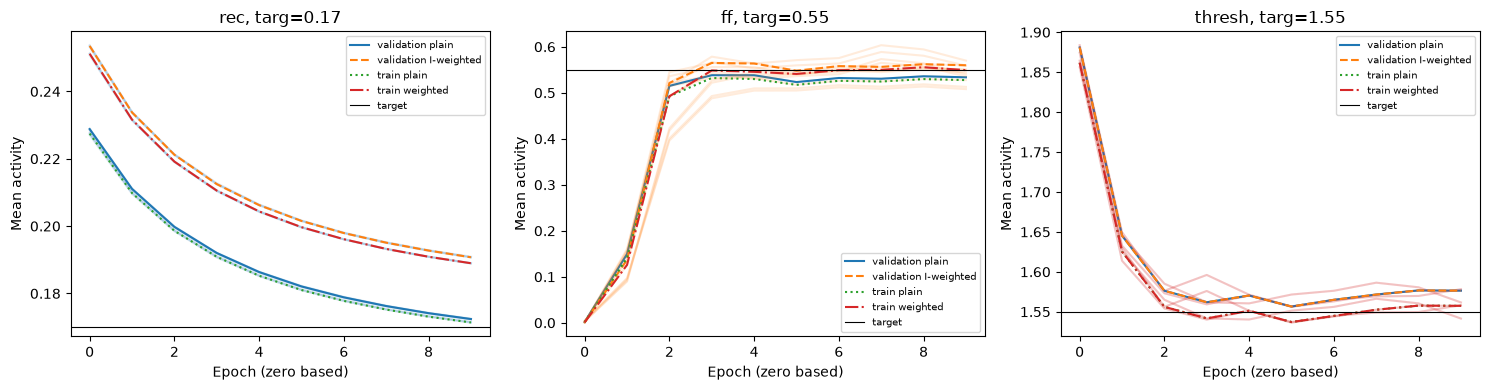

In [9]:
fig, axs = plt.subplots(1, len(models), figsize=FIGSIZE, squeeze=False)
mon = tables["monitor"][tables["monitor"].run.isin(chosen_paths)]
for ax, model in zip(axs[0], models):
    g = mon[mon.model_code == model]
    # Faint curves retain seed runs; styled curves show the median at each epoch.
    for key, label, style in (("rate_mean", "validation plain", "-"), ("rate_wmean", "validation I-weighted", "--"),
                               ("rate_mean_train", "train plain", ":"), ("rate_wmean_train", "train weighted", "-.")):
        for _, r in g.groupby("run"):
            ax.plot(r.epoch, r[key], alpha=.15, color=COLORS[model])
        med = g.groupby("epoch")[key].median()
        ax.plot(med.index, med, linestyle=style, label=label)
    ax.axhline(targets[model], color="black", linewidth=.8, label="target")
    ax.set(title=f"{model}, targ={targets[model]:g}", xlabel="Epoch (zero based)", ylabel="Mean activity")
    ax.legend(fontsize=7)
figures["G2_mean_activity"] = fig

figures['G2_mean_activity'] = fig
for axis in fig.axes:
    if X_LIMITS is not None: axis.set_xlim(X_LIMITS)
    if Y_LIMITS is not None: axis.set_ylim(Y_LIMITS)
if not fig.get_constrained_layout(): fig.tight_layout()
if SHOW_FIGURES: display(fig)
plt.close(fig)

### Final residuals

Edit size and optional axis limits below; the drawing cell reuses the
prepared numbers. Residual curves use Matplotlib's default colors.

In [10]:
FIGSIZE = (5*len(models), 4)
COLORS = dict(MODEL_COLORS)
# Set limits to (min, max); None keeps the figure defaults.
X_LIMITS = None
Y_LIMITS = None

def arm_color(arm):
    return COLORS.get(arm.split("_")[0], "#777777" if arm == "raw" else "#2ca02c")

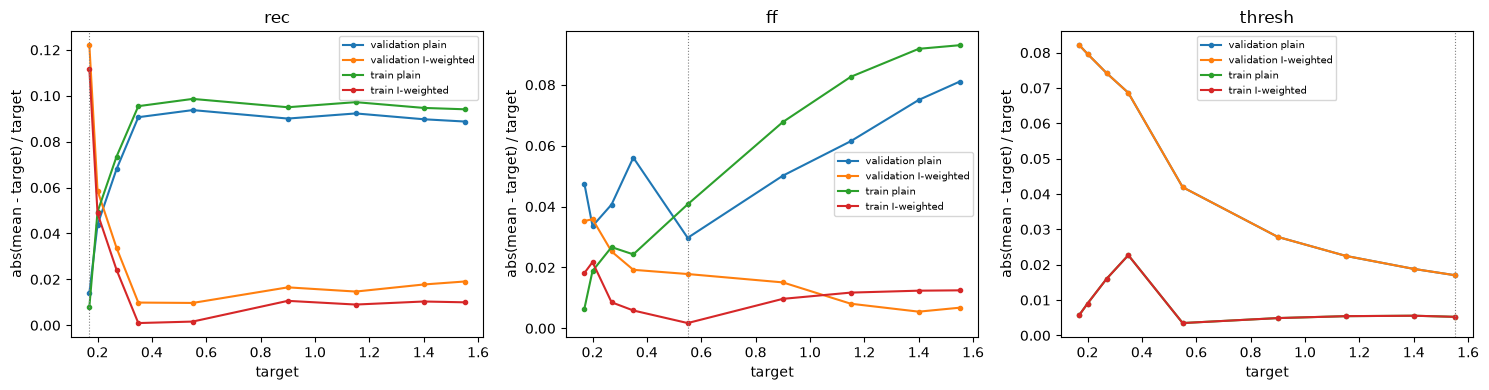

In [11]:
fig, axs = plt.subplots(1, len(models), figsize=FIGSIZE, squeeze=False)
# Take each run's final epoch before taking seed medians at each target.
last = tables["monitor"].sort_values("epoch").groupby("run").tail(1)
for ax, model in zip(axs[0], models):
    for key, label in (("residual_mean", "validation plain"), ("residual_wmean", "validation I-weighted"),
                       ("residual_mean_train", "train plain"), ("residual_wmean_train", "train I-weighted")):
        g = last[last.model_code == model].groupby("targ")[key].median()
        ax.plot(g.index, g, marker=".", label=label)
    ax.axvline(targets[model], color="gray", linestyle=":", linewidth=.8)
    ax.set(title=model, xlabel="target", ylabel="abs(mean - target) / target")
    ax.legend(fontsize=7)
figures["G2_residuals"] = fig

figures['G2_residuals'] = fig
for axis in fig.axes:
    if X_LIMITS is not None: axis.set_xlim(X_LIMITS)
    if Y_LIMITS is not None: axis.set_ylim(Y_LIMITS)
if not fig.get_constrained_layout(): fig.tight_layout()
if SHOW_FIGURES: display(fig)
plt.close(fig)

### Save this chapter (optional)

Set this switch to True and choose a new export name. Save the notebook before
running this cell. Other chapters and notebooks do not need to be exported first.

In [12]:
SAVE_SECTION = False
SECTION_EXPORT_NAME = 'activity_v1'
if SAVE_SECTION:
    export_section(SECTION_EXPORT_NAME, ['G2_mean_activity', 'G2_residuals'], ['monitor'])

## 4. Parameter trajectories

Every saved update is plotted, including initialization. Vertical lines mark epoch boundaries. One figure is kept per selected model and seed.

### Parameters at every update



Edit size, colors, and optional axis limits here; the drawing cell reuses the prepared numbers.

In [13]:
FIGSIZE = (7, 4)
COLORS = dict(MODEL_COLORS)
# Set limits to (min, max); None keeps the figure defaults.
X_LIMITS = None
Y_LIMITS = None

def arm_color(arm):
    return COLORS.get(arm.split("_")[0], "#777777" if arm == "raw" else "#2ca02c")

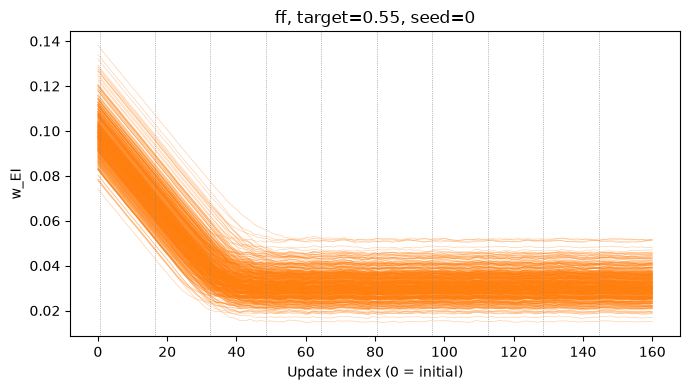

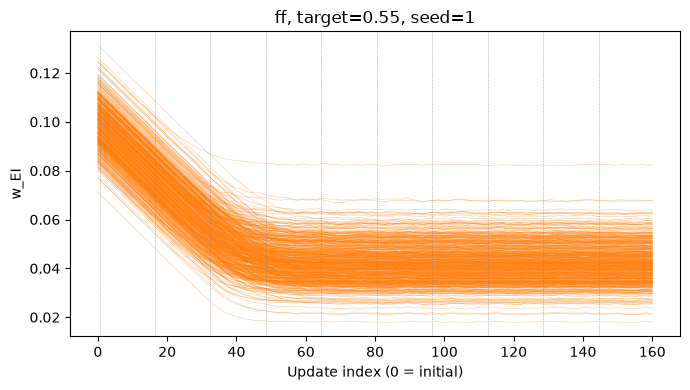

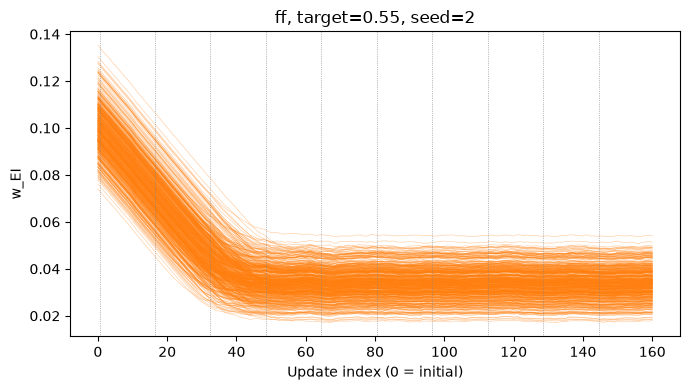

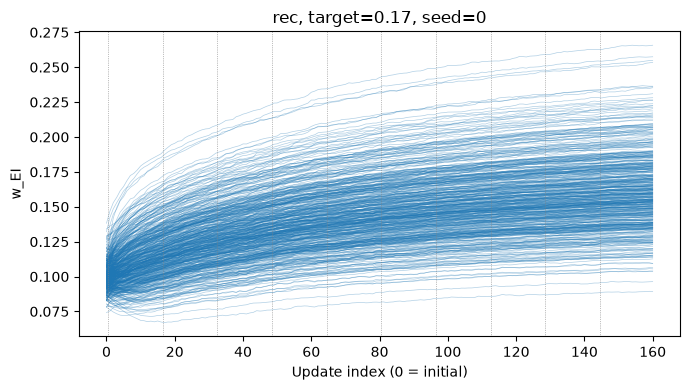

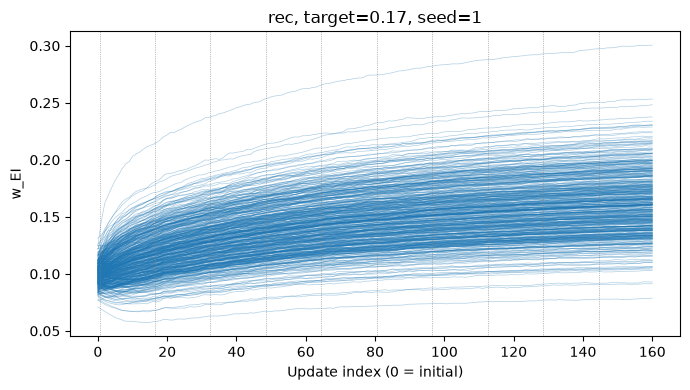

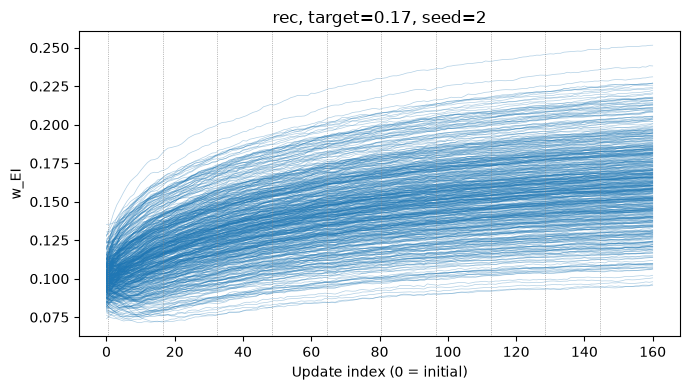

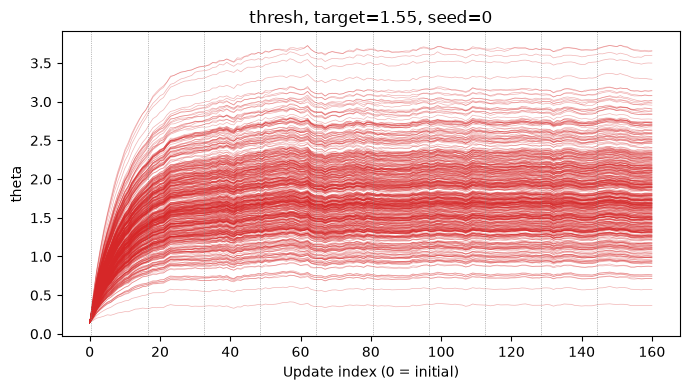

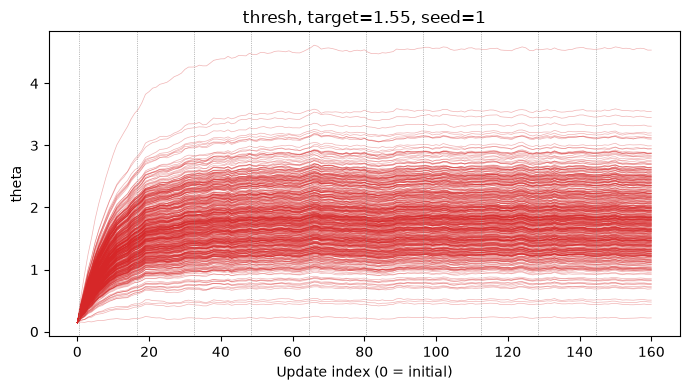

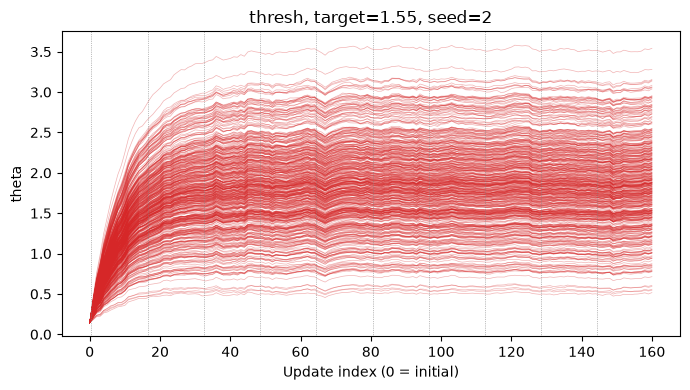

In [14]:
for path, (c, a, _) in selected.items():
    if c["representation"] != "sparse_trained":
        continue
    spec = c["spec"]
    q = a["summaries"]
    fig, ax = plt.subplots(figsize=FIGSIZE)
    # Rows are initial/post-update snapshots; each column traces one parameter.
    ax.plot(q["param_trajectory"], alpha=.35, linewidth=.5, color=COLORS[spec["model_code"]])
    # Half-step offsets place separators between snapshots, including initial -> epoch 0.
    for step in np.flatnonzero(np.diff(q["trajectory_epoch"]) != 0) + 1:
        ax.axvline(step-.5, color="gray", linewidth=.5, linestyle=":")
    parameter = "theta" if spec["model_code"] == "thresh" else "w_EI"
    ax.set(title=f"{spec['model_code']}, target={spec['targ']}, seed={spec['seed_index']}",
           xlabel="Update index (0 = initial)", ylabel=parameter)
    figures[f"G2_parameter_{spec['model_code']}_seed-{spec['seed_index']}"] = fig

for name, figure in figures.items():
    if not name.startswith("G2_parameter_"):
        continue
    for axis in figure.axes:
        if X_LIMITS is not None: axis.set_xlim(X_LIMITS)
        if Y_LIMITS is not None: axis.set_ylim(Y_LIMITS)
    figure.tight_layout()
    if SHOW_FIGURES: display(figure)
    plt.close(figure)

### Save this chapter (optional)

Set this switch to True and choose a new export name. Save the notebook before
running this cell. Other chapters and notebooks do not need to be exported first.

In [15]:
SAVE_SECTION = False
SECTION_EXPORT_NAME = 'parameters_v1'
if SAVE_SECTION:
    export_section(SECTION_EXPORT_NAME, [name for name in figures if name.startswith("G2_parameter_")], ['monitor'])

## 5. Training-order activity and fixed points (AD-01 / RF-01)

`RUN_ADDITIONAL_INFERENCE` defaults to False. Enable it only to compute
a new numeric snapshot from saved parameters, without learning updates.
Choose an unused `ADDITIONAL_PATH` and save the notebook before computing;
then return the switch to False. Reusing an existing path for computation
is rejected. Use a new path when inputs, targets, or computation change.

With the switch off, the chapter loads a completed snapshot whose hashes,
inputs, and targets match the current session, then redraws without inference.
If `ADDITIONAL_PATH` is absent, it reports that and leaves additional tables
and figures empty.

Activity follows epoch-start warm states, shuffle order regenerated from the recorded seed, and saved pre-update parameters. The moving average uses a 1% window (minimum five) with zero-padded edges. Fixed-point tables use every sample in the recorded analysis split of each final trained model. Relative error divides by the per-sample maximum absolute membrane potential. Zero denominators remain undefined. I is not applicable for thresh.

Mode decay is `log(1e-4)/log(spectral_radius)`, a local estimate, not a bound on nonlinear convergence. Tables distinguish real/complex roots, ReLU boundaries, active-set switches, and noncontracting modes. Probe and final-feature checks retain the measured differences and equality flags for every model and seed.

In [16]:
from hnn2.data import load_dataset
from hnn2.saved_inference import training_order_activity, fixed_point_detail

if RUN_ADDITIONAL_INFERENCE:
    if ADDITIONAL_PATH.exists():
        raise FileExistsError("Choose a new ADDITIONAL_PATH before computing")
    activities, probes, fixed_points, state_arrays = [], [], [], {}
    for path, (c, a, _) in selected.items():
        if c["representation"] != "sparse_trained":
            continue
        identity = _identity(path, c)
        dataset = load_dataset(c["input"]["path"])
        # Replay activity with pre-update parameters, then probe the final model.
        activity, probe = training_order_activity(c, a, dataset)
        detail, endpoint, states = fixed_point_detail(c, a, dataset)
        if not np.isfinite(activity.population_activity).all():
            raise ValueError(f"Nonfinite replay activity: {path}")
        # Preserve the original smoothing rule, including zero-padded run edges.
        window = max(int(len(activity)*0.01), 5)
        activity["moving_average"] = np.convolve(activity.population_activity, np.ones(window)/window, mode="same")
        activity["moving_window"] = window
        activities.append(activity.assign(**identity))
        probes.append(pd.concat([probe, endpoint], ignore_index=True).assign(**identity))
        fixed_points.append(detail.assign(**identity))
        state_arrays[f"states_{identity['model_code']}_seed-{identity['seed_index']}"] = states
        print(identity["arm"], identity["seed_index"], probe[["stage", "max_abs_error", "equal"]].to_dict("records"))
    extra_tables = {"training_order_activity": pd.concat(activities, ignore_index=True),
                    "inference_checks": pd.concat(probes, ignore_index=True),
                    "fixed_point_detail": pd.concat(fixed_points, ignore_index=True)}
    # Summarize each run; finite-value counts show the sample support for each metric.
    rows = []
    for coords, frame in extra_tables["fixed_point_detail"].groupby(KEYS, dropna=False):
        row = dict(zip(KEYS, coords))
        row.update(samples=len(frame), active_switch_samples=int(frame.active_set_switch_next_step.sum()),
                   mode_defined=int(frame.mode_decay_steps.notna().sum()),
                   mode_undefined=int(frame.mode_decay_steps.isna().sum()))
        for column in ("E_abs_error", "I_abs_error", "E_relative_error", "I_relative_error",
                       "active_units", "spectral_radius", "mode_decay_steps", "gain_E", "gain_I"):
            values = frame[column][np.isfinite(frame[column])]
            row.update({column+"_n": len(values), column+"_median": values.median(), column+"_max": values.max()})
        for kind in ("real_roots", "complex_pair", "repeated_root"):
            row[kind+"_samples"] = int(frame.root_kind.eq(kind).sum())
        rows.append(row)
    extra_tables["fixed_point_summary"] = pd.DataFrame(rows)
    details = {"ids": ["AD-01", "RF-01"], "training": False,
        "activity": "train split; epoch-start warm state; saved shuffle; pre-update parameters",
        "moving_average": "max(int(n_observations*0.01),5); numpy convolve same; zero-padded edges",
        "fixed_point": "final trained model; every sample in the recorded analysis split",
        "relative_denominator": "per-sample maximum absolute membrane potential over E or I units",
        "mode_estimate": "log(1e-4)/log(spectral_radius); local mode decay, not a nonlinear convergence bound",
        "mode_undefined": "ReLU boundary, nonfinite, noncontracting, or repeated root; reasons in detail table",
        "probe_discrepancy": "User accepted the observed FF seed 0 discrepancy on 2026-09-16; record all differences without relabeling equality"}
    save_figure_tables(ADDITIONAL_PATH, extra_tables, runs, targets=targets,
        selection_directory=selection_directory, notebook_path=NOTEBOOK_PATH,
        coverage=coverage, analysis_targets=effective, arrays=state_arrays, details=details)

    # Keep effective settings and the shared settings source with this snapshot.
    (ADDITIONAL_PATH / "figure_settings.py").write_bytes((ROOT / "notebooks/figure_settings.py").read_bytes())
    (ADDITIONAL_PATH / "notebook_settings.json").write_text(json.dumps({
        "results": str(RESULTS.resolve()), "effective_targets": targets,
        "additional_path": str(ADDITIONAL_PATH.resolve()), "details": details}, indent=2), encoding="utf-8")
    numeric_hashes = {p.name: hashlib.sha256(p.read_bytes()).hexdigest()
                      for p in ADDITIONAL_PATH.iterdir() if p.is_file()}
    (ADDITIONAL_PATH / "numeric_sha256.json").write_text(json.dumps(numeric_hashes, indent=2), encoding="utf-8")
    print("Saved additional numeric analysis:", ADDITIONAL_PATH)

In [17]:
# Read only completed, unchanged numeric snapshots matching the current inputs.
extra_tables, extra_figures = {}, {}
extra_metadata = None
if ADDITIONAL_PATH.exists():
    if not (ADDITIONAL_PATH / "COMPLETE").is_file():
        raise ValueError("Additional analysis is incomplete; use a new path")
    numeric_hashes = json.loads((ADDITIONAL_PATH / "numeric_sha256.json").read_text(encoding="utf-8"))
    for name, digest in numeric_hashes.items():
        if hashlib.sha256((ADDITIONAL_PATH / name).read_bytes()).hexdigest() != digest:
            raise ValueError(f"Additional numeric source changed: {name}")
    extra_metadata = json.loads((ADDITIONAL_PATH / "conditions.json").read_text(encoding="utf-8"))
    current_sources = [{"path": path, "sha256": c["loaded_source_sha256"]}
                       for path, (c, _, _) in runs.items()]
    if extra_metadata["source"] != current_sources or extra_metadata["display_targets"] != targets:
        raise ValueError("Additional analysis belongs to different inputs or targets")
    # Match HP selection and run-population provenance before reusing the tables.
    for key in ("selection", "population_sources"):
        if extra_metadata[key] != coverage.attrs["figure_sources"][key]:
            raise ValueError(f"Additional analysis has different {key}")
    extra_tables = {p.stem: pd.read_csv(p, float_precision="round_trip")
                    for p in ADDITIONAL_PATH.glob("*.csv")}
    print("Loaded additional analysis:", ADDITIONAL_PATH)
else:
    print("Additional analysis is absent. Enable its computation switch explicitly to create it.")

Loaded additional analysis: outputs\synthetic_long_v1\analysis\notebook_figures_v2\additional\adaptation_v1


In [18]:
if extra_tables:
    display(extra_tables["inference_checks"])
    display(extra_tables["fixed_point_summary"])
    display(extra_tables["fixed_point_detail"].head(12))
    display(extra_tables["fixed_point_detail"].groupby(["arm", "undefined_reason"], dropna=False).size().rename("samples"))

,stage,max_abs_error,rtol,atol,equal,run,arm,model_code,targ,eta,seed_index
0,ep00,0.000006,0.00001,1.000000e-08,False,[local path],ff_trained,ff,0.55,0.0001,0
1,ep09,0.000010,0.00001,1.000000e-08,False,[local path],ff_trained,ff,0.55,0.0001,0
2,final_test,0.000000,0.00001,1.000000e-08,True,[local path],ff_trained,ff,0.55,0.0001,0
3,ep00,0.000008,0.00001,1.000000e-08,False,[local path],ff_trained,ff,0.55,0.0001,1
4,ep09,0.000011,0.00001,1.000000e-08,False,[local path],ff_trained,ff,0.55,0.0001,1
5,final_test,0.000000,0.00001,1.000000e-08,True,[local path],ff_trained,ff,0.55,0.0001,1
6,ep00,0.000007,0.00001,1.000000e-08,False,[local path],ff_trained,ff,0.55,0.0001,2
7,ep09,0.000011,0.00001,1.000000e-08,False,[local path],ff_trained,ff,0.55,0.0001,2
8,final_test,0.000000,0.00001,1.000000e-08,True,[local path],ff_trained,ff,0.55,0.0001,2
9,ep00,0.000002,0.00001,1.000000e-08,False,[local path],rec_trained,rec,0.17,0.0010,0


,run,arm,model_code,targ,eta,seed_index,samples,active_switch_samples,mode_defined,mode_undefined,...,mode_decay_steps_max,gain_E_n,gain_E_median,gain_E_max,gain_I_n,gain_I_median,gain_I_max,real_roots_samples,complex_pair_samples,repeated_root_samples
0,[local path],ff_trained,ff,0.55,0.0001,0,1024,4,1024,0,...,184.206807,1024,2.541494,2.541494,1024,20.504166,20.504166,1024,0,0
1,[local path],ff_trained,ff,0.55,0.0001,1,1024,0,1024,0,...,184.206807,1024,2.541494,2.541494,1024,20.504166,20.504166,1024,0,0
2,[local path],ff_trained,ff,0.55,0.0001,2,1024,0,1024,0,...,184.206807,1024,2.541494,2.541494,1024,20.504166,20.504166,1024,0,0
3,[local path],rec_trained,rec,0.17,0.0010,0,1024,0,1024,0,...,114.028740,1024,2.541494,2.541494,1024,20.504166,20.504166,0,1024,0
4,[local path],rec_trained,rec,0.17,0.0010,1,1024,0,1024,0,...,125.257344,1024,2.541494,2.541494,1024,20.504166,20.504166,0,1024,0
5,[local path],rec_trained,rec,0.17,0.0010,2,1024,0,1024,0,...,120.092150,1024,2.541494,2.541494,1024,20.504166,20.504166,0,1024,0
6,[local path],thresh_trained,thresh,1.55,0.1000,0,1024,0,1024,0,...,18.420681,1024,2.541494,2.541494,0,NaN,NaN,1024,0,0
7,[local path],thresh_trained,thresh,1.55,0.1000,1,1024,0,1024,0,...,18.420681,1024,2.541494,2.541494,0,NaN,NaN,1024,0,0
8,[local path],thresh_trained,thresh,1.55,0.1000,2,1024,0,1024,0,...,18.420681,1024,2.541494,2.541494,0,NaN,NaN,1024,0,0


,active_units,relu_boundary,coupling_k,root_kind,lambda1_real,lambda1_imag,lambda2_real,lambda2_imag,dec_E,dec_I,...,I_abs_error,I_relative_denominator,I_relative_error,I_reason,run,arm,model_code,targ,eta,seed_index
0,377,False,NaN,real_roots,0.606531,0.0,0.951229,0.0,0.606531,0.951229,...,0.000740,33.819492,0.000022,NaN,[local path],ff_trained,ff,0.55,0.0001,0
1,348,False,NaN,real_roots,0.606531,0.0,0.951229,0.0,0.606531,0.951229,...,0.001062,26.342655,0.000040,NaN,[local path],ff_trained,ff,0.55,0.0001,0
2,474,False,NaN,real_roots,0.606531,0.0,0.951229,0.0,0.606531,0.951229,...,0.001123,24.934851,0.000045,NaN,[local path],ff_trained,ff,0.55,0.0001,0
3,376,False,NaN,real_roots,0.606531,0.0,0.951229,0.0,0.606531,0.951229,...,0.000202,54.457737,0.000004,NaN,[local path],ff_trained,ff,0.55,0.0001,0
4,355,False,NaN,real_roots,0.606531,0.0,0.951229,0.0,0.606531,0.951229,...,0.001171,23.745066,0.000049,NaN,[local path],ff_trained,ff,0.55,0.0001,0
5,385,False,NaN,real_roots,0.606531,0.0,0.951229,0.0,0.606531,0.951229,...,0.000706,34.975719,0.000020,NaN,[local path],ff_trained,ff,0.55,0.0001,0
6,347,False,NaN,real_roots,0.606531,0.0,0.951229,0.0,0.606531,0.951229,...,0.000946,29.052681,0.000033,NaN,[local path],ff_trained,ff,0.55,0.0001,0
7,458,False,NaN,real_roots,0.606531,0.0,0.951229,0.0,0.606531,0.951229,...,0.000523,61.753357,0.000008,NaN,[local path],ff_trained,ff,0.55,0.0001,0
8,309,False,NaN,real_roots,0.606531,0.0,0.951229,0.0,0.606531,0.951229,...,0.001289,21.294785,0.000061,NaN,[local path],ff_trained,ff,0.55,0.0001,0
9,311,False,NaN,real_roots,0.606531,0.0,0.951229,0.0,0.606531,0.951229,...,0.000225,45.668709,0.000005,NaN,[local path],ff_trained,ff,0.55,0.0001,0


arm             undefined_reason
ff_trained      NaN                 3072
rec_trained     NaN                 3072
thresh_trained  NaN                 3072
Name: samples, dtype: int64

### Display settings and drawing

For style changes, rerun these two cells only. Numeric snapshots remain unchanged.

In [19]:
ACTIVITY_FIGSIZE = (10, 4)
ACTIVITY_COLORS = dict(MODEL_COLORS)
RAW_COLOR = "gray"
ACTIVITY_X_LIMITS = None
ACTIVITY_Y_LIMITS = None

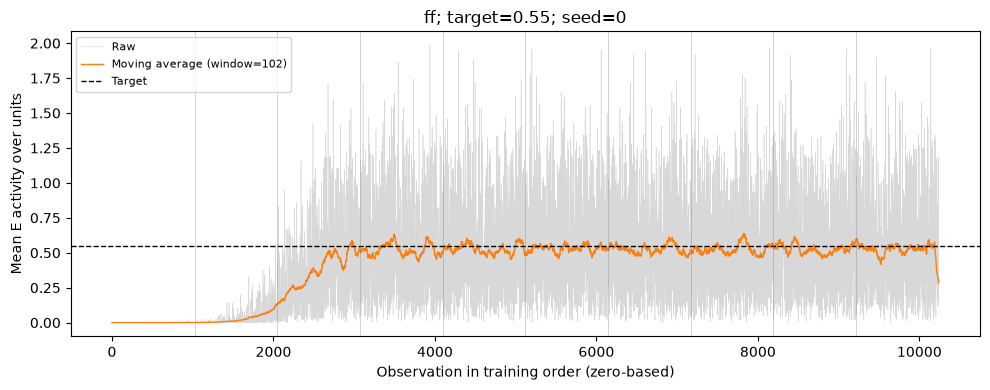

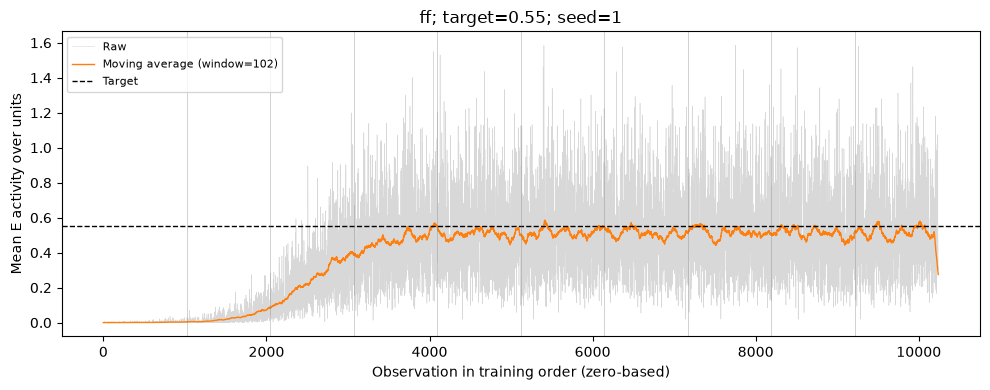

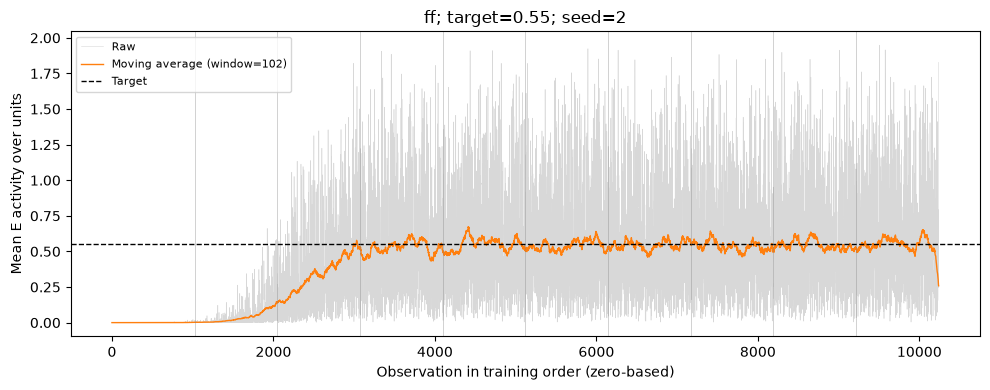

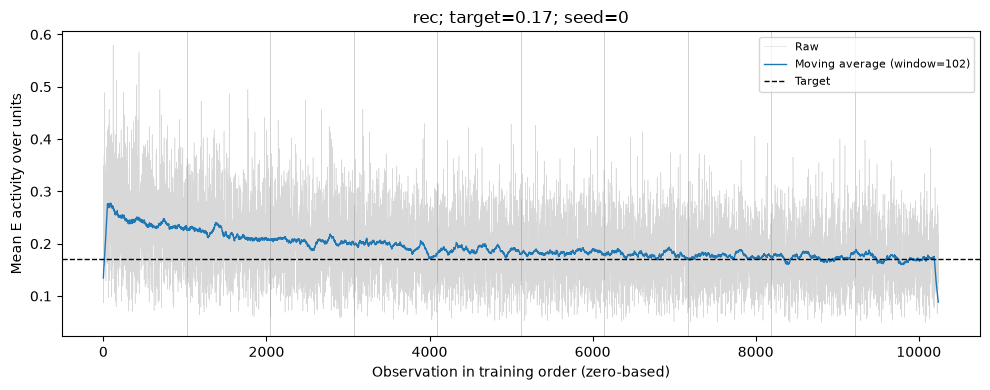

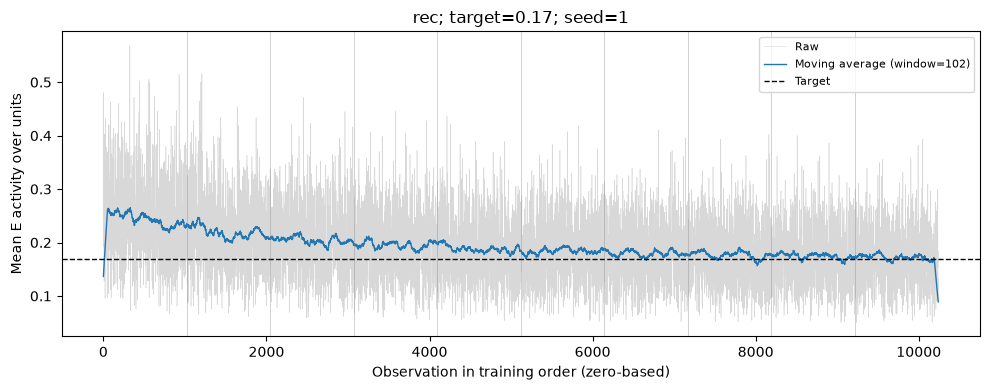

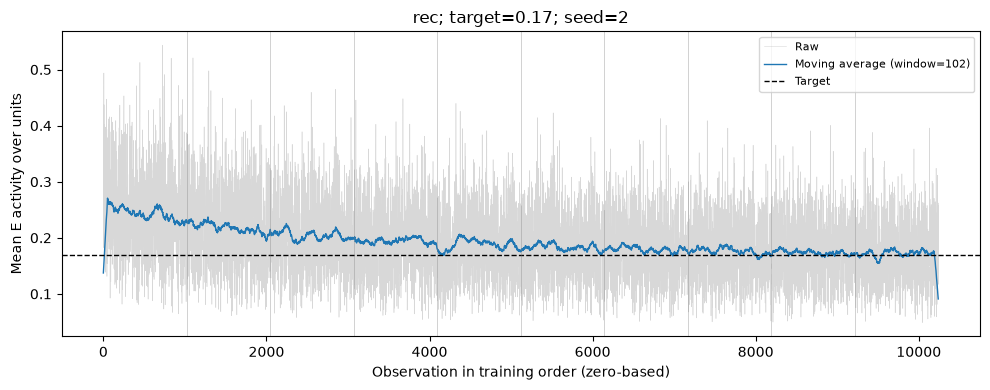

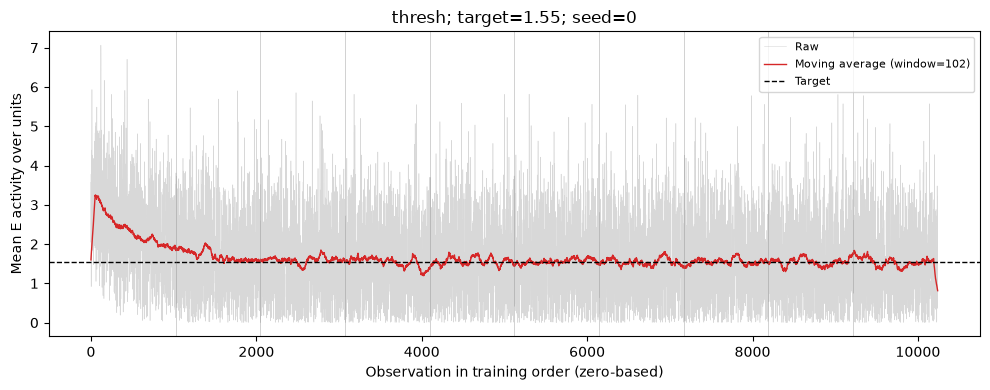

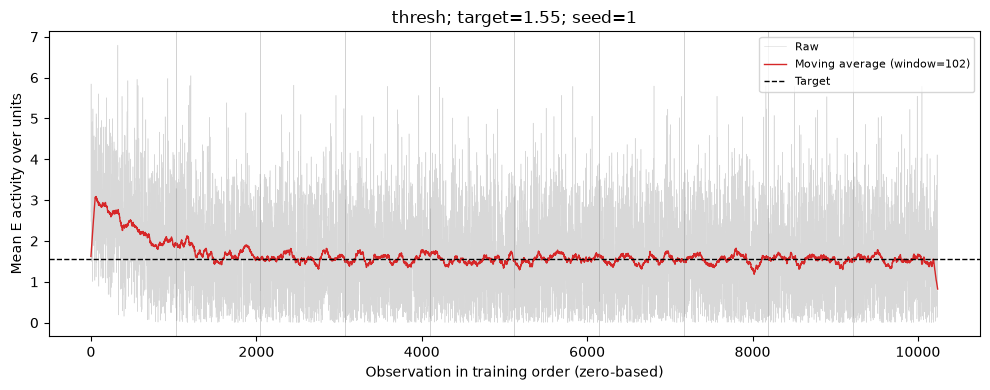

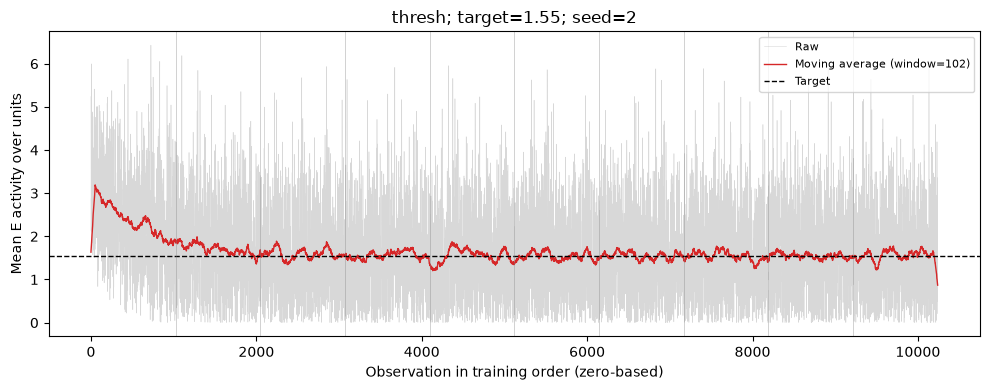

In [20]:
extra_figures = {}
if extra_tables:
    for run, frame in extra_tables["training_order_activity"].groupby("run", sort=False):
        # order_index follows shuffled presentations across epochs, not dataset row IDs.
        frame = frame.sort_values("order_index")
        first = frame.iloc[0]
        model, seed = first.model_code, int(first.seed_index)
        fig, ax = plt.subplots(figsize=ACTIVITY_FIGSIZE)
        ax.plot(frame.order_index, frame.population_activity, color=RAW_COLOR, alpha=.3, lw=.4, label="Raw")
        ax.plot(frame.order_index, frame.moving_average, color=ACTIVITY_COLORS[model], lw=1, label=f"Moving average (window={int(first.moving_window)})")
        ax.axhline(first.targ, color="black", ls="--", lw=1, label="Target")
        for boundary in frame.groupby("epoch").order_index.min().iloc[1:]:
            ax.axvline(boundary, color="gray", lw=.5, alpha=.5)
        ax.set(xlabel="Observation in training order (zero-based)", ylabel="Mean E activity over units",
               title=f"{model}; target={first.targ:g}; seed={seed}")
        if ACTIVITY_X_LIMITS is not None: ax.set_xlim(ACTIVITY_X_LIMITS)
        if ACTIVITY_Y_LIMITS is not None: ax.set_ylim(ACTIVITY_Y_LIMITS)
        ax.legend(fontsize=8)
        fig.tight_layout()
        extra_figures[f"G2_training_order_{model}_seed-{seed}"] = fig
        if SHOW_FIGURES: display(fig)
        plt.close(fig)

### Save additional figures

After loading a numeric snapshot and drawing its figures, set
`SAVE_ADDITIONAL_FIGURES=True` and choose a new `ADDITIONAL_EXPORT_NAME`.
PNG/PDF switches control the image formats. The images record the path
and hashes of the numbers in `ADDITIONAL_PATH`; those numbers are not copied.
The final export also includes these figures when they have been prepared.

In [21]:
def export_additional_figures(destination):
    """Export prepared figures with a hash link to the saved additional numbers."""
    if not extra_figures:
        print("No additional figures prepared")
        return
    # Recheck after plotting so exported figures refer to unchanged numeric sources.
    for name, digest in numeric_hashes.items():
        if hashlib.sha256((ADDITIONAL_PATH / name).read_bytes()).hexdigest() != digest:
            raise ValueError(f"Additional numeric source changed: {name}")
    save_basic_figures(extra_figures, destination, png=SAVE_PNG, pdf=SAVE_PDF,
                       numeric_source=ADDITIONAL_PATH)

SAVE_ADDITIONAL_FIGURES = False
ADDITIONAL_EXPORT_NAME = "additional_v1"  # New name for every presentation change.
if SAVE_ADDITIONAL_FIGURES:
    if Path(ADDITIONAL_EXPORT_NAME).name != ADDITIONAL_EXPORT_NAME or ADDITIONAL_EXPORT_NAME in ("", ".", ".."):
        raise ValueError("Use a simple new export name")
    export_additional_figures(OUTPUT / NOTEBOOK_OWNER / ADDITIONAL_EXPORT_NAME / "figures")

## Export all figures and tables in this notebook

Run all main chapters first. Set `SAVE_NUMBERS=True` in Settings and choose
a new `EXPORT_NAME`. This saves the CSVs listed in `OWNED_TABLES`, prepared
main-chapter figures in the enabled formats, input/HP/population hashes,
effective targets, a notebook copy, and export settings.

Chapter exports must use different names. Save the notebook file before
exporting; after style changes, rerun the drawing cells and use a new name.

If the additional figures have been prepared, this export also saves them
under `additional_figures/` in the enabled formats. Their numeric tables
remain in `ADDITIONAL_PATH`; the image export records that path and its hashes.
Loading and redrawing a completed snapshot requires no new computation.

In [22]:
print("Tables owned by this notebook:", OWNED_TABLES)
print("Figures prepared:", list(figures))
if SAVE_NUMBERS:
    export_section(EXPORT_NAME, list(figures), OWNED_TABLES)
else:
    print("Preview only. Enable SAVE_NUMBERS and choose a new EXPORT_NAME to export.")
if SAVE_NUMBERS and extra_figures:
    export_additional_figures(OUTPUT / NOTEBOOK_OWNER / EXPORT_NAME / "additional_figures")

Tables owned by this notebook: ['monitor']
Figures prepared: ['G2_mean_activity', 'G2_residuals', 'G2_parameter_ff_seed-0', 'G2_parameter_ff_seed-1', 'G2_parameter_ff_seed-2', 'G2_parameter_rec_seed-0', 'G2_parameter_rec_seed-1', 'G2_parameter_rec_seed-2', 'G2_parameter_thresh_seed-0', 'G2_parameter_thresh_seed-1', 'G2_parameter_thresh_seed-2']
Preview only. Enable SAVE_NUMBERS and choose a new EXPORT_NAME to export.
